# Проверка гипотез и A/B-анализ
- Автор: Васильев Арсений
- Дата: 20.08.2026

## Цели и задачи проекта

**Цель:** провести анализ поведения пользователей сервиса Яндекс Книги и оценить результаты A/B-теста для интернет-магазина BitMotion Kit.

**Задачи:**
- Проверить статистическую гипотезу о разнице в активности пользователей из Москвы и Санкт-Петербурга;
- Оценить корректность проведения A/B-теста по изменению интерфейса;
- Рассчитать конверсию в покупку и проверить статистическую значимость изменений;
- Подготовить аналитические выводы по результатам исследования.

## Описание данных

**Часть 1. Яндекс Книги (проверка гипотезы)**

Данные представлены в файле `yandex_knigi_data.csv` и содержат агрегированную информацию о пользователях сервиса Яндекс Книги из Москвы и Санкт-Петербурга за период с сентябрь по ноябрь 2024 года.

Структура:
- `puid` - уникальный идентификатор пользователя
- `city` - город пользователя (Москва или Санкт-Петербург)
- `hours` - суммарное количество часов чтения и прослушивания контента

**Часть 2. BitMotion Kit (анализ A/B-теста)**

Данные представлены двумя файлами, содержащими информацию об A/B-тестировании интерфейса.

Таблица участников теста (`ab_test_participants.csv`):
- `user_id` - уникальный идентификатор пользователя
- `group` - группа пользователя в A/B-тесте (A - контрольная группа, B - тестовая)
- `ab_test` - название теста (в данном проекте анализируется тест interface_eu_test)
- `device` - устройство, с которого произошла регистрация пользователя

Таблица событий (`ab_test_events.zip`):
- `user_id` - уникальный идентификатор пользователя
- `event_dt` - дата и время совершения события
- `event_name` - тип события (registration или purchase)
- `details` - дополнительные данные о событии

## Содержимое проекта

[Часть 1. Проверка гипотезы в Python и составление аналитической записки](#Часть-1.-Проверка-гипотезы-в-Python-и-составление-аналитической-записки)
   1. [Загрузка данных и знакомство с ними](#1.-Загрузка-данных-и-знакомство-с-ними)
   2. [Проверка гипотезы в Python](#2.-Проверка-гипотезы-в-Python)
   3. [Аналитическая записка](#3.-Аналитическая-записка)
   
[Часть 2. Анализ результатов A/B-тестирования](#Часть-2.-Анализ-результатов-A/B-тестирования)
   1. [Цели и задачи](#1.-Цели-и-задачи)
   2. [Загрузка данных и оценка целостности](#2.-Загрузка-данных-и-оценка-целостности)
   3. [Оценка корректности проведения теста](#3.-Оценка-корректности-проведения-теста)
   4. [Оценка результатов A/B-тестирования](#4.-Оценка-результатов-A/B-тестирования)

# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Загрузим файл `yandex_knigi_data.csv` с пользователями из Москвы и Санкт-Петербурга и их суммарной активностью в часах. Сразу проверим данные на дубликаты по `puid`, сравним размеры групп и посмотрим на распределение.

**Гипотеза:** пользователи из Санкт-Петербурга в среднем больше времени проводят в приложении, чем москвичи.

Проверим её односторонним t-тестом для двух независимых выборок:

- $H_0$: $\mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ - среднее время активности в СПб не больше, чем в Москве
- $H_1$: $\mu_{\text{СПб}} > \mu_{\text{Москва}}$ - в СПб активность выше, и это различие статистически значимо

По итогам анализа подготовим аналитическую записку: какой тест выбрали, какой получили p-value, как его интерпретировать и какие могут быть причины такого результата.

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv', index_col=0)

display(df.head())
display(df.info())

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


None

In [3]:
# проверка на явные дубликаты пользователей
duplicates_count = df['puid'].duplicated().sum()
print(f'Количество дубликатов puid: {duplicates_count}')

if duplicates_count > 0:
    df = df.drop_duplicates(subset=['puid'])

Количество дубликатов puid: 244


In [4]:
# сравнение размеров групп
display(df['city'].value_counts())

city
Москва             6234
Санкт-Петербург    2306
Name: count, dtype: int64

In [5]:
# описательные статистики по часам в разрезе городов
stat = df.groupby('city')['hours']
display(stat.describe())

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,6234.0,10.881092,36.851683,0.000018,0.059903,0.924498,5.939972,857.209373
Санкт-Петербург,2306.0,11.264433,39.831755,0.000025,0.060173,0.875355,6.138424,978.764775


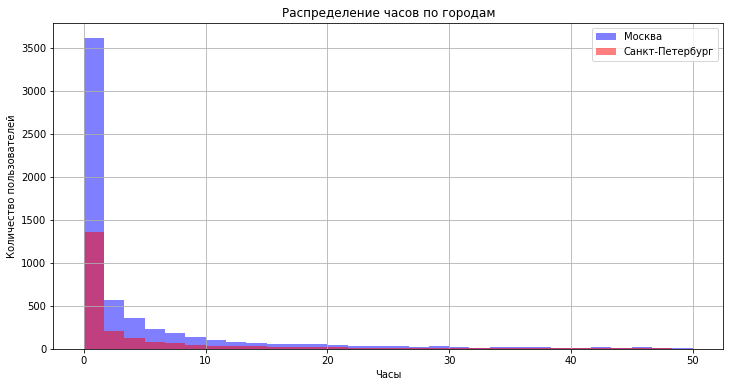

In [6]:
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

plt.figure(figsize=(12, 6))
plt.hist(moscow, bins=30, range=(0, 50), alpha=0.5, label='Москва', color='blue')
plt.hist(spb, bins=30, range=(0, 50), alpha=0.5, label='Санкт-Петербург', color='red')

plt.title('Распределение часов по городам')
plt.xlabel('Часы')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()

plt.show()

**Вывод:**
- Загружено 8784 записи, найдено и удалено 244 дубликата по идентификатору пользователя `puid`, а также лишний служебный столбец `Unnamed: 0`.
- После очистки: 6234 пользователя из Москвы и 2306 из Санкт-Петербурга. Группы неравные, что ожидаемо из-за разницы в населении городов.
- Среднее время активности: Москва - 10.88ч, Санкт-Петербург - 11.26ч.
- Медианы значительно ниже средних (0.92 и 0.87ч соответственно), что говорит о сильном перекосе вправо, большинство пользователей активны менее 1 часа, но есть единичные пользователи с очень высокой активностью.

## 2. Проверка гипотезы в Python

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [7]:
alpha = 0.05

moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

# односторонний тест Уэлча
result = stats.ttest_ind(spb, moscow, equal_var=False, alternative='greater')

print(f'p-value: {result.pvalue:.3f}')

if result.pvalue < alpha:
    print("Отвергаем H0: пользователи из СПб читают статистически значимо больше.")
else:
    print("Не отвергаем H0: нет доказательств, что в СПб читают больше.")

p-value: 0.344
Не отвергаем H0: нет доказательств, что в СПб читают больше.


## 3. Аналитическая записка

**1. Выбранный тип теста и уровень значимости**

- Для проверки гипотезы был выбран односторонний t-тест Уэлча, тк классический t-тест Стьюдента предполагает равенство дисперсий и размеров выборок. В наших данных размеры групп существенно различаются (Москва - 6234, Санкт-Петербург - 2306), а стандартные отклонения также не равны (36.85 и 39.83).

- Уровень значимости alpha = 0.05 - стандартный порог в продуктовых A/B-тестированиях, он обеспечивает баланс между ошибками 1 и 2 рода.

**2. Результат теста**

- p-value = 0.344, не можем отвергнуть нулевую гипотезу.

**3. Интерпретация результатов**

- Так как p-value (0.344) больше выбранного уровня значимости (0.05), у нас нет статистических оснований отвергнуть нулевую гипотезу. Наблюдаемая разница в средних значениях (11.26ч в СПб и 10.88ч в Москве) является статистически незначимой. Мы не можем утверждать, что пользователи из Санкт-Петербурга проводят в приложении больше времени.

**4. Возможные причины полученных результатов**

- Аудиокниги и чтение обычно встроены в повседневные привычки, например, во время поездки в транспорте, прогулки или сна, поэтому люди в Москве и Петербурге ведут себя похоже.
- На то, сколько времени человек проводит в приложении, больше влияют его личные особенности: возраст, интересы, свободное время, привык ли он слушать аудиокниги и тд. В обоих городах эти характеристики распределены примерно одинаково, поэтому город не сильно влияет на активность пользователей.

----

# Часть 2. Анализ результатов A/B-тестирования

В этой части проекта необходимо проанализировать данные A/B-теста для интернет-магазина BitMotion Kit. Компания продает геймифицированные товары для здорового образа жизни. Пользователи жалуются на сложный интерфейс сайта, что мешает привлечению новых клиентов и росту продаж. Команда разработала новую версию интерфейса и протестировала её на части аудитории, чтобы увеличить долю зарегистрированных пользователей, совершающих покупку.

## 1. Цели и задачи

**Цель исследования:** оценить результаты A/B-теста, целью которого было упрощение интерфейса сайта для увеличения конверсии зарегистрированных пользователей в покупателей.

**Задачи:**
- Проверить корректность проведения теста;
- Оценить выборку;
- Рассчитать конверсию в покупку для контрольной и тестовой групп;
- Проверить статистическую значимость изменений конверсии;
- Определить, был ли достигнут ожидаемый эффект - рост конверсии минимум на 3 процентных пункта.

## 2. Загрузка данных и оценка целостности

In [8]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)

display(participants.head())
display(participants.info())

display(events.head())
display(events.info())

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


None

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


None

## 3. Оценка корректности проведения теста

Выделим пользователей, участвующих в целевом тесте, и проверим выполнение трех ключевых условий:
- соответствие данных техническому заданию;
- равномерность распределения участников между контрольной (A) и тестовой (B) группами;
- отсутствие пересечений (один пользователь не должен находиться в обеих группах одновременно).

In [9]:
# создаем колнку с информацией о тесте и группой
participants['ab_test_group'] = participants['ab_test'] + '_' + participants['group']

# группируем по user_id
user_groups_count = participants.groupby('user_id')['ab_test_group'].nunique()

# оставляем только тех кто участвует в одном месте и одной группе
clean_user_ids = user_groups_count[user_groups_count == 1].index

# убираем лишних пользователей
filtered_participants = participants[participants['user_id'].isin(clean_user_ids)]

# отбираем только участников нашего теста
test_users = filtered_participants[filtered_participants['ab_test'] == 'interface_eu_test']

print(f'Всего участников в тесте interface_eu_test: {len(test_users)}')

display(test_users['group'].value_counts())

Всего участников в тесте interface_eu_test: 9963


group
B    5011
A    4952
Name: count, dtype: int64

**Вывод:**

- Распределение по группам практически равномерное (A - 4952, B - 5011), разница незначительна.
- Дубликаты отсутствуют, ни один пользователь не попал одновременно в контрольную и тестовую группы.

Проанализируем данные о пользовательской активности по таблице `ab_test_events`, оставим только нужные события.

In [10]:
# оставляем только нужный тест и убираем global
test_events = events[
    (events['user_id'].isin(test_users['user_id'])) & 
    (events['user_id'] != 'GLOBAL')]

# находим дату регистрации каждого пользователя
registrations = test_events[test_events['event_name'] == 'registration'][['user_id', 'event_dt']]
registrations = registrations.rename(columns={'event_dt': 'registration_dt'})

# объединяем все события с датой регистрации
test_events = test_events.merge(registrations, on='user_id', how='inner')

print(f'Всего событий участников теста: {len(test_events)}')
display(test_events.head())

Всего событий участников теста: 73815


,user_id,event_dt,event_name,details,registration_dt
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20


Теперь определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации.

In [11]:
# считаем разницу между событием и регистрацией
test_events['lifetime_days'] = (test_events['event_dt'] - test_events['registration_dt']).dt.total_seconds() / 86400

# оставляем события в течение первых 7 суток
test_events = test_events[test_events['lifetime_days'] <= 7]

print(f'Событий в первые 7 дней после регистрации: {len(test_events)}')
display(test_events.head())

Событий в первые 7 дней после регистрации: 63805


,user_id,event_dt,event_name,details,registration_dt,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.0


Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии - 30%;
- мощность теста - 80%;
- достоверность теста - 95%.

In [12]:
conv = 0.30
mde = 0.03
power = 0.80
alpha = 0.05

effect_size = proportion_effectsize(conv, conv + mde)

# расчет размера выборки
power_analysis = NormalIndPower()
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    ratio = 1.0,
    alpha = alpha,
    power = power
)

print(f'Необходимый размер выборки для каждой группы: {int(sample_size)}')

Необходимый размер выборки для каждой группы: 3761


**Вывод:**

При базовой конверсии 30%, ожидаемом эффекте +3 пп, мощности 80% и уровне значимости 5% необходимый размер одной группы составляет 3761 пользователь. Размеры групп (A - 5383, B - 5467) превышают это значение, значит выборка достаточна для получения статистически значимых результатов A/B-теста.

Рассчитаем для каждой группы количество посетителей, покупателей и конверсию.

In [13]:
# добавляем информацию о группе
test_events = test_events.merge(test_users[['user_id', 'group']], on='user_id', how='left')

# уникальные посетители по группам
visitors = test_events.groupby('group')['user_id'].nunique()

# уникальные покупатели по группам
buyers = test_events[test_events['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()

print('Посетители:')
display(visitors)

print('Покупатели:')
display(buyers)

print('Конверсия:')
display(buyers / visitors)

Посетители:


group
A    4952
B    5011
Name: user_id, dtype: int64

Покупатели:


group
A    1377
B    1480
Name: user_id, dtype: int64

Конверсия:


group
A    0.278069
B    0.295350
Name: user_id, dtype: float64

**Вывод:**

В тестовой группе конверсия в покупку составила 29.54%, контрольной группе - 27.81%. Абсолютный прирост конверсии +1.73 пп, но это значение ниже целевого порога +3 пп. Для окончательного вывода о статистической значимости необходимо провести статистический тест.

## 4. Оценка результатов A/B-тестирования

Проверим статистическую значимость изменения конверсии с помощью Z-теста для пропорций. Также оценим, можем ли мы отвергнуть нулевую гипотезу и подтвердить, что наблюдаемый рост в тестовой группе не является случайностью.

In [14]:
alpha = 0.05

stat, p_value = proportions_ztest(
    [buyers['B'], buyers['A']],
    [visitors['B'], visitors['A']],
    alternative='larger'
)

print(f'p-value: {p_value:.3f}')

if p_value < alpha:
    print('Отвергаем H0: конверсия в тестовой группе статистически значимо выше.')
else:
    print('Не отвергаем H0: нет доказательств, что конверсия в тестовой группе выше.')

p-value: 0.028
Отвергаем H0: конверсия в тестовой группе статистически значимо выше.


**Вывод:**
1. Статистическая значимость: p-value = 0.028 ниже уровня значимости 0.05, значит мы отвергаем нулевую гипотезу и делаем вывод, что новый интерфейс статистически значимо увеличил конверсию в покупку по сравнению со старым.
2. Бизнес-эффект: конверсия выросла с 27.81% до 29.54%, абсолютный прирост составил +1.73 пп, значит на каждые 1000 посетителей приходится примерно на 17 покупок больше.
3. Достижение ожидаемого эффекта: несмотря на статистическую значимость, целевой порог +3 пп не был достигнут. Фактический прирост оказался на 1.27 пп ниже. Эффект есть, но он меньше запланированного.